# D6 stage C: pressure at the axis
This study computes the axis pressure from the ideal azimuthal schedule specified in Lemma A.5, then supplies it to the leading-inner solver. The selected finite schedule is not a certified realization of the full outer construction.

See the [article](../../writing/d6_axis_pressure/article.html) and [source notes](../../writing/d6_axis_pressure/source-notes.md) for the exact intervals, numerical method, and B.2 bound.

In [1]:
import csv
import json
from dataclasses import replace
import mpmath as mp
from IPython.display import display, Image
from nscomp.pressure import Schedule, pressure_trace
from nscomp.d6c import load_parameters, generate, STUDY, WRITING

p = load_parameters()
summary = generate()
trace = pressure_trace(Schedule(**p["schedule"]), p["quadrature_order"])
print(json.dumps(p, indent=2))

{
  "study": "D6 stage C: axis pressure from the source's ideal azimuthal schedule",
  "schedule": {
    "M_d": 2.0,
    "intermediate_lambda": 0.02,
    "h": 1e-09,
    "interpolation_length": 100.0,
    "terminal_c": 0.01,
    "log_amplitude_margin": 1.0
  },
  "amplitude_definition": "log(P_star)=exp(M_d)+10+log_amplitude_margin",
  "quadrature_order": 128,
  "reference_order": 256,
  "quadrature_scan": [
    8,
    16,
    32,
    64,
    128
  ],
  "eta_samples": 101,
  "inner_handoff": {
    "eta": 0.2,
    "Y": 1.0,
    "degrees": [
      4,
      8,
      12,
      16
    ],
    "digits": 70,
    "offset_j": 0.02,
    "regularization_sigma": 0.0001,
    "Lambda_over_P_squared": 100.0,
    "amplitude_C": 10000.0
  },
  "B2_delta": 1.0,
  "tail_cut_offsets": [
    0,
    5,
    10,
    20
  ],
  "units": "dimensionless source similarity quantities; no physical SI calibration",
  "scope": "Declared finite schedule satisfying the displayed scalar hierarchy; sufficient large/small t

## The full pressure datum
The initial power-law branch contributes exactly -2.5*f(eta)^2 to Pi0/P_star squared. All other pressure contributions have the same sign. The final sum is independent of the later radial scale X_R.

eta=0: normalized pressure=-3.31462272979, eta derivative=-0
eta=0.2: normalized pressure=-3.06455503864, eta derivative=2.35735002972
eta=0.5: normalized pressure=-2.12135854707, eta derivative=3.39417367531
eta=1: normalized pressure=-0.828655682449, eta derivative=1.6573113649
Initial-branch fraction at the center: 0.7542336500404307


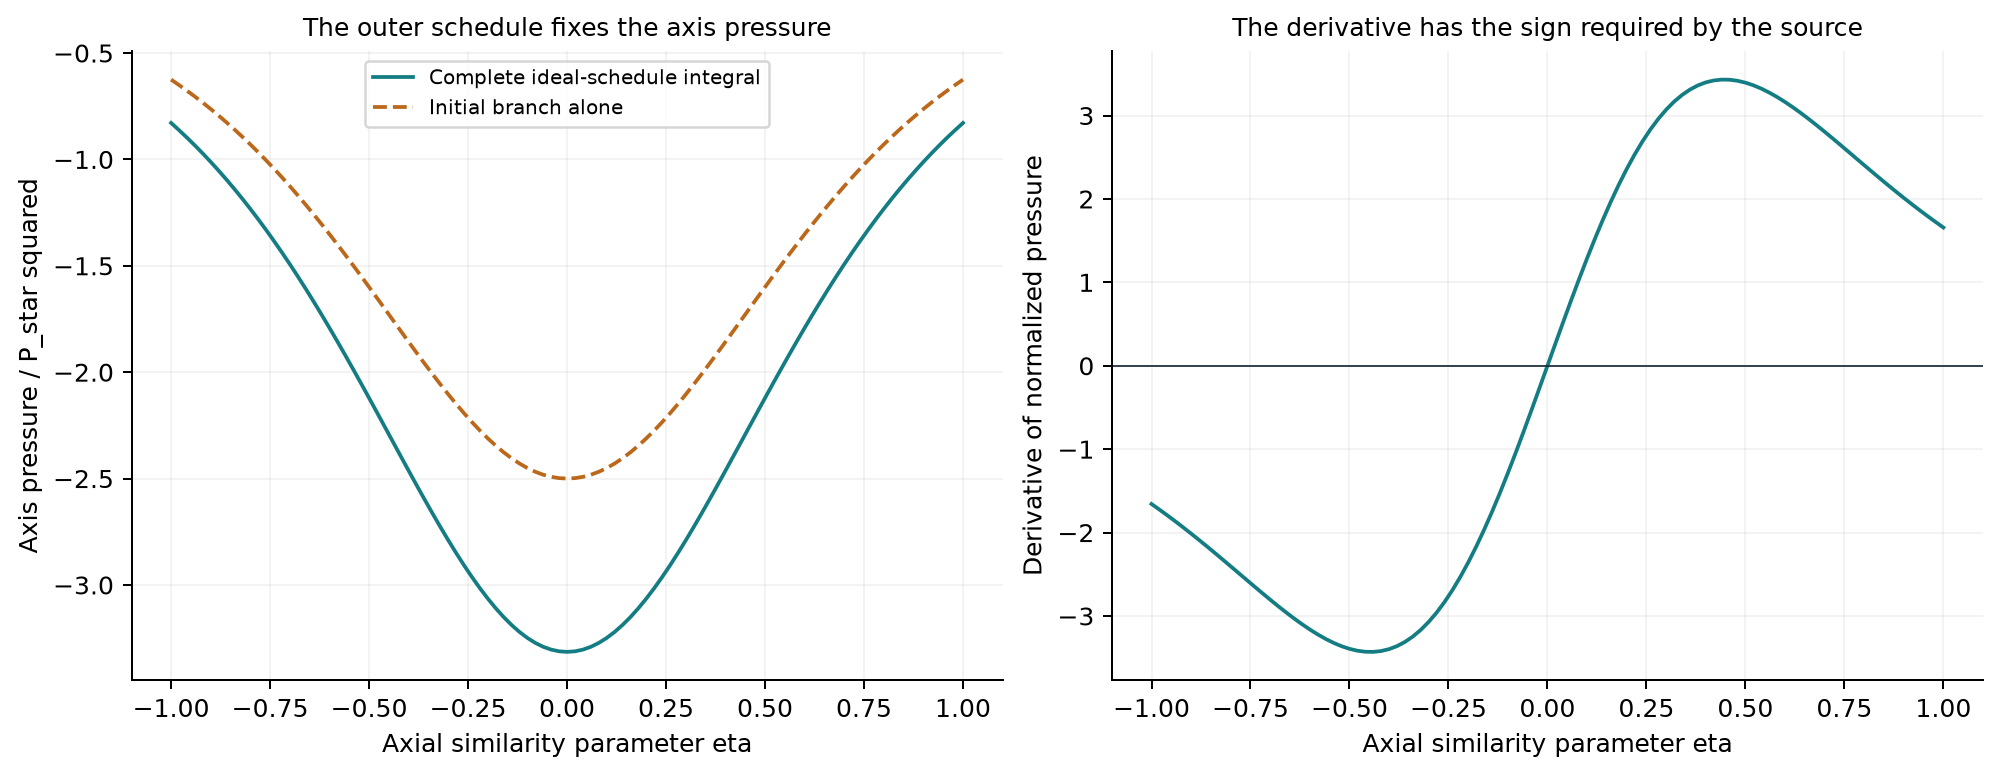

In [2]:
for eta in (0, 0.2, 0.5, 1):
    print(f"eta={eta:g}: normalized pressure={trace.normalized(eta):.12g}, "
          f"eta derivative={trace.normalized(eta, 1):.12g}")
print("Initial-branch fraction at the center:",
      summary["pressure_initial_branch_fraction"])
display(Image(filename=str(WRITING / "figures/01_source_axis_pressure.png")))

## Keep the long radial schedule and tiny contributions in logarithms
The terminal radius ratio exceeds direct binary64 range. Several pressure contributions lie below its smallest positive value. Their logarithms remain finite and are exported separately.

Tail starts at log10(X/X_R) = 537.0559017844506
initial power: log10 magnitude = 0.397940
initial slope transition: log10 magnitude = -0.319245
axial decrease interval: log10 magnitude = -0.474748
intermediate slope transition: log10 magnitude = -8.227439
reserved intermediate interval: log10 magnitude = -8.486733
axial pulse interval: log10 magnitude = -114.502461
remove eta dependence: log10 magnitude = -408.085531
uniform angular correction interval: log10 magnitude = -453.854217
release to steep slope: log10 magnitude = -507.110813
steep power interval: log10 magnitude = -508.199444
release to heat exponent: log10 magnitude = -616.181502
wait for terminal Q target: log10 magnitude = -616.590911
terminal smooth factor: log10 magnitude = -628.448798
infinite exterior power: log10 magnitude = -629.729502


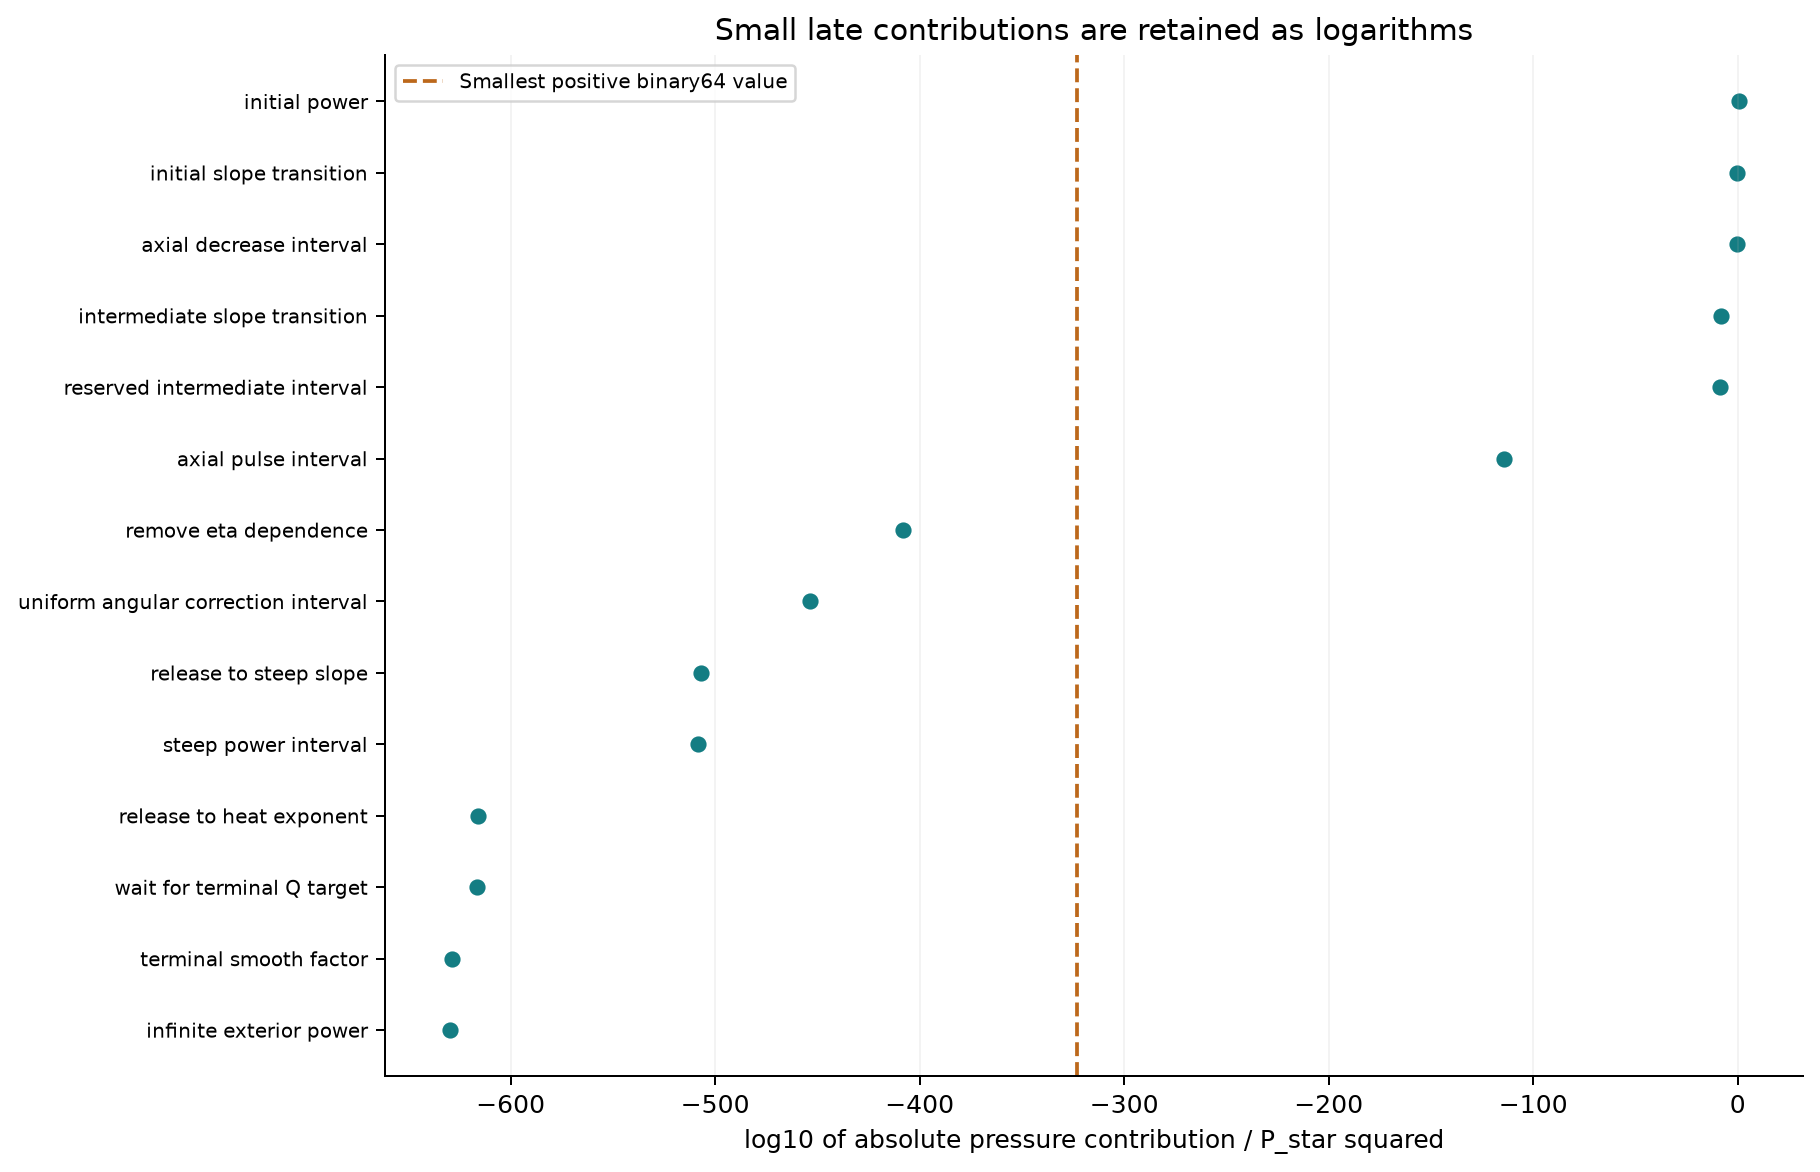

In [3]:
def rows(name):
    with (STUDY / "data" / name).open(encoding="utf-8", newline="") as stream:
        return list(csv.DictReader(stream))

print("Tail starts at log10(X/X_R) =", summary["tail_start_log10_radius"])
for row in rows("pressure_contributions.csv"):
    print(f'{row["stage"]}: log10 magnitude = '
          f'{float(row["log10_normalized_pressure_magnitude"]):.6f}')
display(Image(filename=str(WRITING / "figures/02_pressure_contribution_scales.png")))

## Resolve the integral and then the inner recurrence
The left panel tests quadrature. The right tests local equation consistency for the supplied numerical pressure. Its very small defects do not remove the pressure's binary64 quadrature uncertainty.

nodes = 8 pressure change = 0.0005099759866000753 terminal target relative change = 0.4320955463035303
nodes = 16 pressure change = 1.087726263548916e-05 terminal target relative change = 0.028794524864573012
nodes = 32 pressure change = 5.872502040205063e-09 terminal target relative change = 6.156153750924709e-05
nodes = 64 pressure change = 3.552713678800501e-15 terminal target relative change = 1.4399725856151235e-10
nodes = 128 pressure change = 8.881784197001252e-16 terminal target relative change = 6.994405055138486e-15
Terminal target Q_p: 7.429804677881472e-11
Waiting interval length: 27.25272361810115


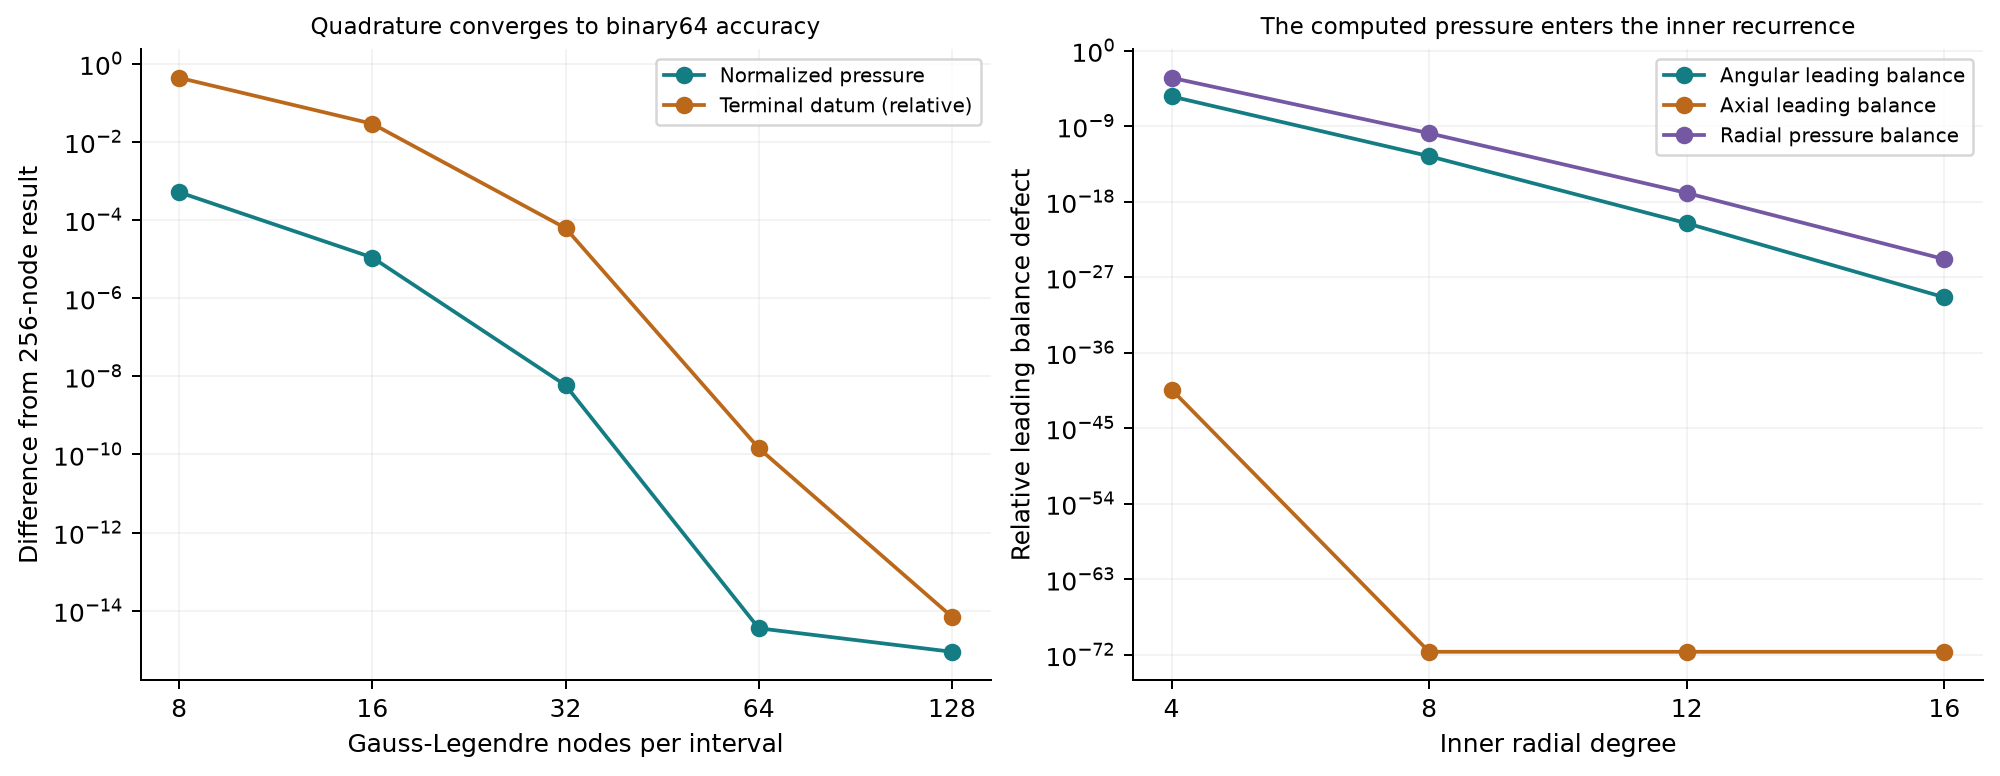

128-to-256-node propagated change: {'quantity': 'Phi', 'absolute_change': '3.404862838905872e-19', 'relative_change': '4.429604966175351e-19'}
128-to-256-node propagated change: {'quantity': 'U', 'absolute_change': '4.481459579371731e-18', 'relative_change': '5.351351840952191e-18'}
128-to-256-node propagated change: {'quantity': 'Pi', 'absolute_change': '7.390303911116256', 'relative_change': '2.568997551279566e-16'}


In [4]:
for row in rows("quadrature_convergence.csv"):
    print("nodes =", row["quadrature_order"],
          "pressure change =", row["max_pressure_difference"],
          "terminal target relative change =", row["relative_Q_target_difference"])
print("Terminal target Q_p:", trace.Q_target)
print("Waiting interval length:", trace.waiting_length)
display(Image(filename=str(WRITING / "figures/03_pressure_and_handoff_convergence.png")))
for row in rows("handoff_quadrature_change.csv"):
    print("128-to-256-node propagated change:", row)

## A sufficient bound for condition B.2
The exact initial pressure contribution and the signs of the remaining terms confine small Z_star to a narrow band. An algebraic lower bound on H_star throughout that band gives chi>0.99. This is one condition, separate from the full parameter hierarchy, global amplitude bound, exit inequality, stress cone, and joining.

In [5]:
h = p["inner_handoff"]
bound = trace.axis_condition_bound(h["offset_j"], h["regularization_sigma"],
                                  p["B2_delta"])
for key, value in bound.items():
    print(key, "=", value if isinstance(value, bool) else mp.nstr(value, 18))
print("Final local inner handoff:")
print(json.dumps(summary["final_inner_handoff"], indent=2))
print("Joined profile:", summary["joined_profile"])

geometry_bound = 36.2504000323408
eta_band_bound = 3.17460535704778199e-15
H_lower = 0.0199999999999857143
chi_lower = 0.99997500062498434
condition_sufficient = True
Final local inner handoff:
{
  "radial_degree": 16,
  "eta": 0.2,
  "Y": 1.0,
  "Phi": 0.7686606062855599,
  "U": 0.8374443902336132,
  "angular_relative": 3.860236095417719e-30,
  "axial_relative": 2.237276579722073e-72,
  "pressure_relative": 1.362436529216269e-25
}
Joined profile: False


## Explore a declared alternative and an exact exterior remainder
This cell changes M_d locally without altering the published baseline. It defines another finite schedule, not a newly certified construction.
The exterior remainder is integrated analytically, so no radius mesh is needed to extend it.

In [6]:
alternative = pressure_trace(replace(trace.schedule, M_d=1.0), order=128)
print("Alternative normalized center pressure:", alternative.normalized(0))
print("Alternative log amplitude:", alternative.schedule.log_P)
print("Alternative terminal logarithmic radius:", alternative.tail_start_y)
print("Baseline exterior remainder:")
for row in rows("exterior_tail.csv"):
    print(row)
print("Next: global axis-amplitude representation and the inner exit condition, "
      "then annular matching and the first correction; see the D6 ledger.")

Alternative normalized center pressure: -3.314622706557335
Alternative log amplitude: 13.718281828459045
Alternative terminal logarithmic radius: 1231.9461392828787
Baseline exterior remainder:
{'extra_log_radius': '0', 'log10_normalized_pressure_remainder': '-629.7295023256618'}
{'extra_log_radius': '5', 'log10_normalized_pressure_remainder': '-631.900974739521'}
{'extra_log_radius': '10', 'log10_normalized_pressure_remainder': '-634.0724471533802'}
{'extra_log_radius': '20', 'log10_normalized_pressure_remainder': '-638.4153919810987'}
Next: global axis-amplitude representation and the inner exit condition, then annular matching and the first correction; see the D6 ledger.
